In [1]:
import pandas as pd

df = pd.read_csv("../data/train.csv")

df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [3]:
# Insurance Policy Analytics

## Business Problem
This project analyzes health insurance customer data to identify which customers are most likely to be interested in vehicle insurance.

## Tools Used
- Python
- Pandas
- Jupyter Notebook
- Excel
- SQL
- Power BI
- Machine Learning

## Objectives
- Explore customer demographics and policy characteristics
- Identify patterns linked to vehicle insurance interest
- Prepare data for dashboarding in Power BI
- Build a predictive model for customer response


SyntaxError: invalid syntax (405482215.py, line 4)

# Insurance Policy Analytics

## Business Problem
This project analyzes health insurance customer data to identify which customers are most likely to be interested in vehicle insurance.

## Tools Used
- Python
- Pandas
- Jupyter Notebook
- Excel
- SQL
- Power BI
- Machine Learning

## Objectives
- Explore customer demographics and policy characteristics
- Identify patterns linked to vehicle insurance interest
- Prepare data for dashboarding in Power BI
- Build a predictive model for customer response

## 1. Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset


In [6]:
df = pd.read_csv("../data/train.csv")

df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


## 3. Understand the Data

In [7]:
df.shape
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  str    
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  str    
 7   Vehicle_Damage        381109 non-null  str    
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), str(3)
memory usage: 34.9 MB


,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,190555.000000,38.822584,0.997869,26.388807,0.458210,30564.389581,112.034295,154.347397,0.122563
std,110016.836208,15.511611,0.046110,13.229888,0.498251,17213.155057,54.203995,83.671304,0.327936
min,1.000000,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,95278.000000,25.000000,1.000000,15.000000,0.000000,24405.000000,29.000000,82.000000,0.000000
50%,190555.000000,36.000000,1.000000,28.000000,0.000000,31669.000000,133.000000,154.000000,0.000000
75%,285832.000000,49.000000,1.000000,35.000000,1.000000,39400.000000,152.000000,227.000000,0.000000
max,381109.000000,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


## 4. Target Variable Analysis

The `Response` column indicates whether the customer is interested in vehicle insurance.

0 = Not Interested  
1 = Interested

In [8]:
df["Response"].value_counts()

Response
0    334399
1     46710
Name: count, dtype: int64

In [9]:
df["Response"].value_counts(normalize=True) * 100

Response
0    87.743664
1    12.256336
Name: proportion, dtype: float64

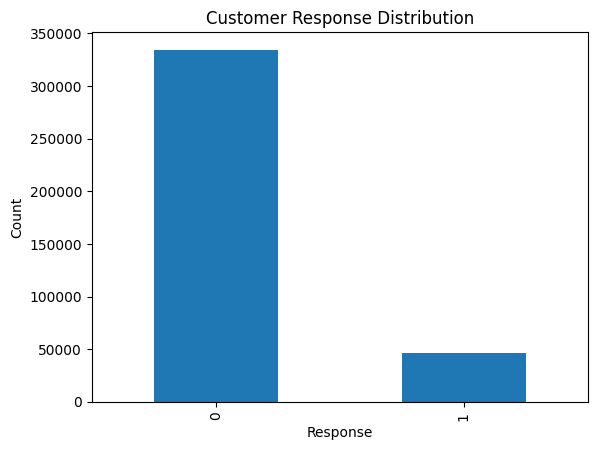

In [10]:
df["Response"].value_counts().plot(kind="bar")

plt.title("Customer Response Distribution")
plt.xlabel("Response")
plt.ylabel("Count")

plt.show()


### Insight

The dataset is highly imbalanced. Most customers are not interested in vehicle insurance, while only a smaller percentage respond positively. This imbalance will be important when building the machine learning model later.

In [11]:
df.shape

(381109, 12)

In [12]:
df["Response"].value_counts()

Response
0    334399
1     46710
Name: count, dtype: int64

## 5. Age vs Insurance Interest

In [13]:
df.groupby("Age")["Response"].mean().head(10)

Age
20    0.027439
21    0.034879
22    0.036396
23    0.036774
24    0.035169
25    0.035569
26    0.035759
27    0.043773
28    0.068754
29    0.101629
Name: Response, dtype: float64

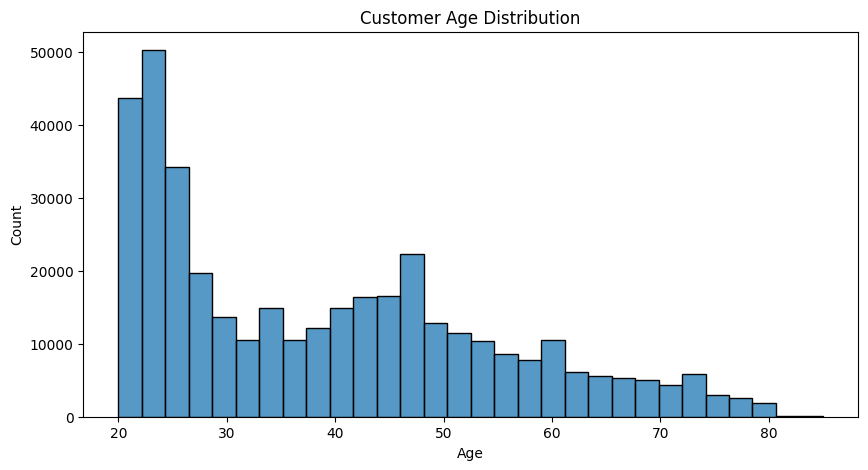

In [14]:
plt.figure(figsize=(10,5))
sns.histplot(df["Age"], bins=30)
plt.title("Customer Age Distribution")
plt.show()

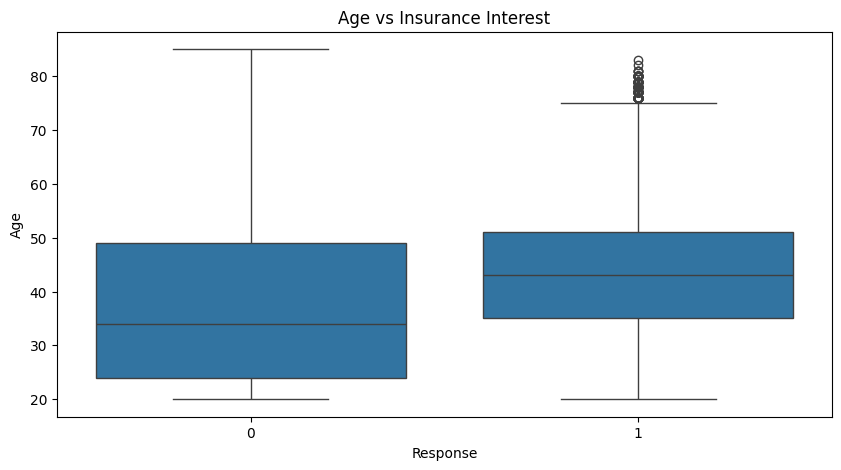

In [15]:
plt.figure(figsize=(10,5))
sns.boxplot(x="Response", y="Age", data=df)
plt.title("Age vs Insurance Interest")
plt.show()

### Insight

The distribution of age suggests that certain age groups are more likely to show interest in vehicle insurance. Understanding this pattern can help insurance companies target marketing campaigns toward the most responsive customer segments.

## 6. Vehicle Age vs Insurance Interest


In [16]:
df["Vehicle_Age"].value_counts()

Vehicle_Age
1-2 Year     200316
< 1 Year     164786
> 2 Years     16007
Name: count, dtype: int64

In [17]:
df.groupby("Vehicle_Age")["Response"].mean()

Vehicle_Age
1-2 Year     0.173755
< 1 Year     0.043705
> 2 Years    0.293746
Name: Response, dtype: float64

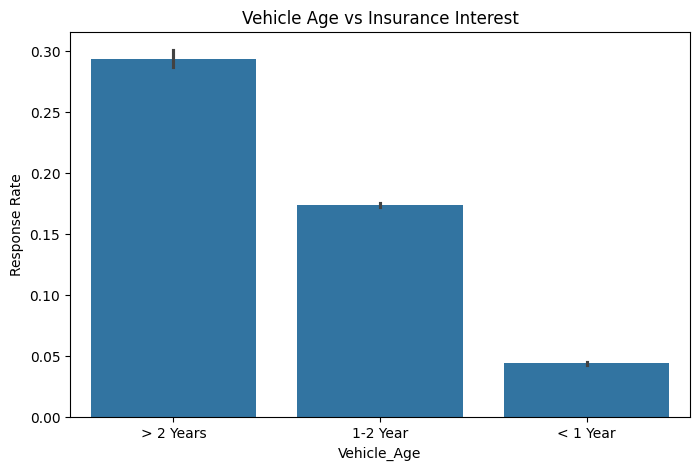

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Vehicle_Age",
    y="Response",
    data=df
)

plt.title("Vehicle Age vs Insurance Interest")
plt.ylabel("Response Rate")
plt.show()

### Insight

Vehicle age appears to significantly influence customer interest in vehicle insurance. Customers with older vehicles may show different purchasing behavior compared to those with newer vehicles. This variable is likely to be an important predictor in the machine learning model later in the analysis.

## 7. Annual Premium Analysis

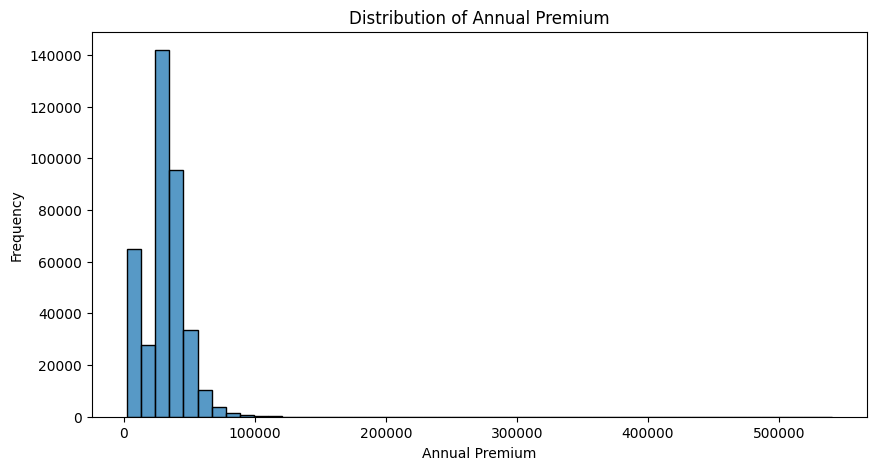

In [19]:
plt.figure(figsize=(10,5))
sns.histplot(df["Annual_Premium"], bins=50)

plt.title("Distribution of Annual Premium")
plt.xlabel("Annual Premium")
plt.ylabel("Frequency")

plt.show()

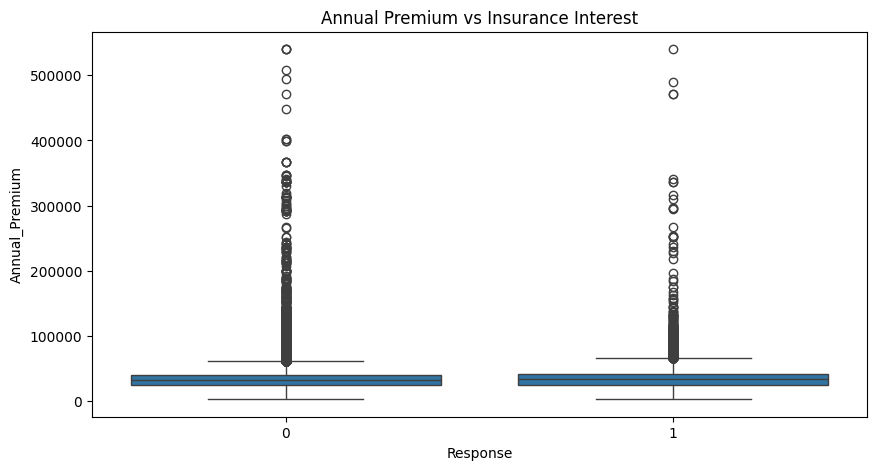

In [20]:
plt.figure(figsize=(10,5))
sns.boxplot(x="Response", y="Annual_Premium", data=df)

plt.title("Annual Premium vs Insurance Interest")
plt.show()

In [21]:
df.isnull().sum()

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

## 8. Feature Preparation for Machine Learning

In [22]:
df_ml = df.copy()

df_ml = pd.get_dummies(df_ml, columns=["Gender", "Vehicle_Age", "Vehicle_Damage"], drop_first=True)

df_ml.head()

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Gender_Male,Vehicle_Age_< 1 Year,Vehicle_Age_> 2 Years,Vehicle_Damage_Yes
0,1,44,1,28.0,0,40454.0,26.0,217,1,True,False,True,True
1,2,76,1,3.0,0,33536.0,26.0,183,0,True,False,False,False
2,3,47,1,28.0,0,38294.0,26.0,27,1,True,False,True,True
3,4,21,1,11.0,1,28619.0,152.0,203,0,True,True,False,False
4,5,29,1,41.0,1,27496.0,152.0,39,0,False,True,False,False


## 9. Define Features and Target

In [23]:
X = df_ml.drop(["Response","id"], axis=1)
y = df_ml["Response"]

X.head()

,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Gender_Male,Vehicle_Age_< 1 Year,Vehicle_Age_> 2 Years,Vehicle_Damage_Yes
0,44,1,28.0,0,40454.0,26.0,217,True,False,True,True
1,76,1,3.0,0,33536.0,26.0,183,True,False,False,False
2,47,1,28.0,0,38294.0,26.0,27,True,False,True,True
3,21,1,11.0,1,28619.0,152.0,203,True,True,False,False
4,29,1,41.0,1,27496.0,152.0,39,False,True,False,False


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 10. Train Machine Learning Model


In [26]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [27]:
from sklearn.metrics import classification_report

predictions = model.predict(X_test)

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.89      0.97      0.93     66699
           1       0.38      0.12      0.18      9523

    accuracy                           0.87     76222
   macro avg       0.63      0.55      0.55     76222
weighted avg       0.82      0.87      0.83     76222



### Model Evaluation

The Random Forest model achieved an overall accuracy of approximately 87%. However, due to class imbalance in the dataset, the model performs much better at predicting customers who are not interested in vehicle insurance than those who are interested.

The recall for the positive class (customers interested in insurance) is relatively low, indicating that the model misses many potential buyers. In real business applications, improving recall for the positive class would be important to ensure that marketing campaigns target as many interested customers as possible.

In [28]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=50,
    max_depth=12,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [29]:
predictions = model.predict(X_test)
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.98      0.68      0.80     66699
           1       0.29      0.92      0.44      9523

    accuracy                           0.71     76222
   macro avg       0.64      0.80      0.62     76222
weighted avg       0.90      0.71      0.76     76222



In [30]:
import pandas as pd

feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

Vehicle_Damage_Yes       0.404349
Previously_Insured       0.326343
Age                      0.092654
Vehicle_Age_< 1 Year     0.058467
Policy_Sales_Channel     0.052525
Region_Code              0.019457
Annual_Premium           0.017249
Vintage                  0.016695
Vehicle_Age_> 2 Years    0.007574
Gender_Male              0.003799
dtype: float64

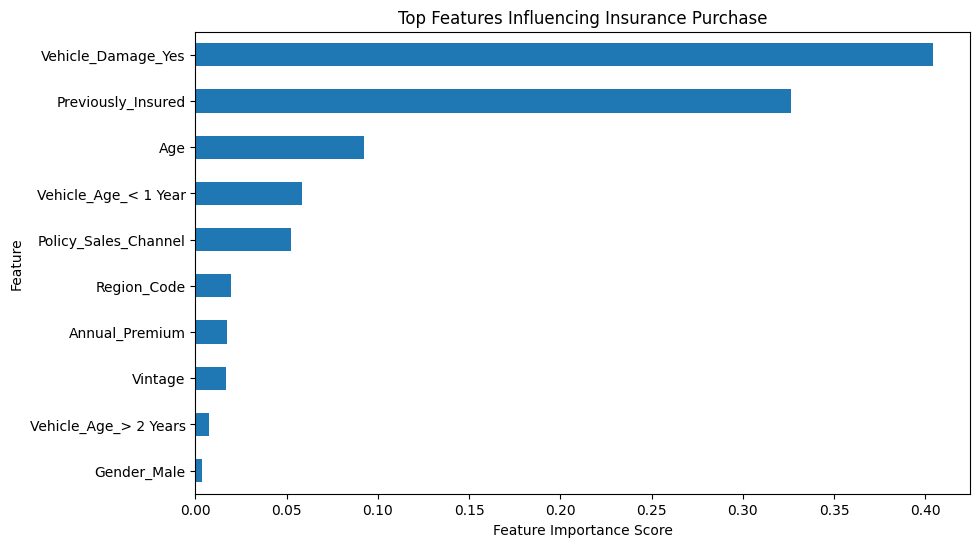

In [31]:
plt.figure(figsize=(10,6))

feature_importance.head(10).plot(kind="barh")

plt.title("Top Features Influencing Insurance Purchase")
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()


### Feature Importance Insight

The model identifies **vehicle damage history** and **previous insurance status** as the strongest predictors of whether a customer will purchase vehicle insurance.

Customers whose vehicles have experienced damage appear significantly more likely to seek insurance coverage. Additionally, customers who are not currently insured represent a key opportunity for cross-selling vehicle insurance products.

These insights could help insurance companies improve marketing strategies by targeting high-probability customer segments.

In [32]:
df.to_csv("../data/insurance_dashboard_data.csv", index=False)

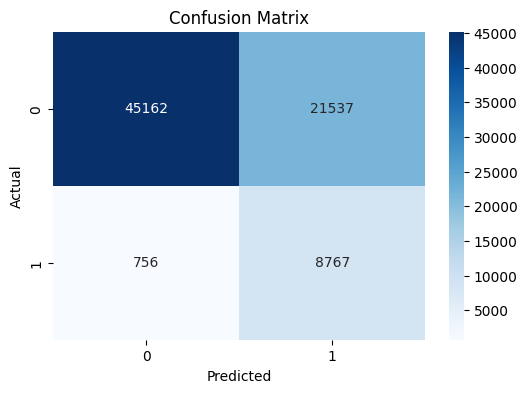

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


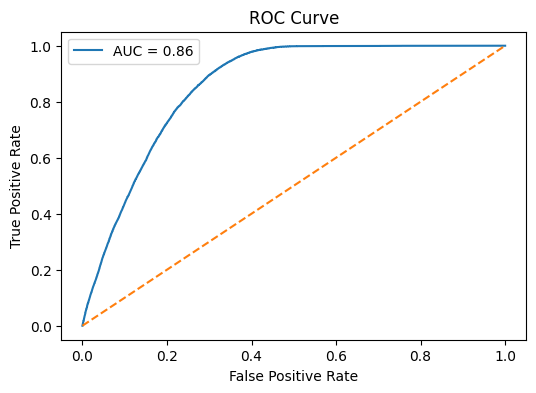

In [35]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

Model Performance Insight

The Random Forest model achieved an AUC score of 0.86, indicating strong predictive capability in distinguishing customers who are likely to purchase vehicle insurance from those who are not.

This suggests the model can effectively support targeted marketing campaigns, enabling insurers to prioritize outreach to customers with the highest predicted purchase probability.

In [37]:
test_results = X_test.copy()

test_results["id"] = df.loc[X_test.index, "id"]

test_results["Actual_Response"] = y_test
test_results["Predicted_Response"] = predictions
test_results["Prediction_Probability"] = y_prob

test_results.to_csv("../data/predicted_insurance_customers.csv", index=False)

In [38]:
test_results.columns


Index(['Age', 'Driving_License', 'Region_Code', 'Previously_Insured',
       'Annual_Premium', 'Policy_Sales_Channel', 'Vintage', 'Gender_Male',
       'Vehicle_Age_< 1 Year', 'Vehicle_Age_> 2 Years', 'Vehicle_Damage_Yes',
       'id', 'Actual_Response', 'Predicted_Response',
       'Prediction_Probability'],
      dtype='str')